In [ ]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.fraud_detection.data_loader import load_raw, reduce_memory
import warnings
warnings.filterwarnings("ignore")

# consistent plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
FIGURES_DIR = "../reports/figures"

In [12]:
df = load_raw("../data/raw")
df = reduce_memory(df)
print(f"Shape: {df.shape}")
print(f"Columns: {df.shape[1]}")
df.head(3)

Shape: (590540, 434)
Columns: 434


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Legitimate transactions : 569,877  (96.5%)
Fraudulent transactions : 20,663  (3.5%)

Imbalance ratio (legit:fraud) : 27:1


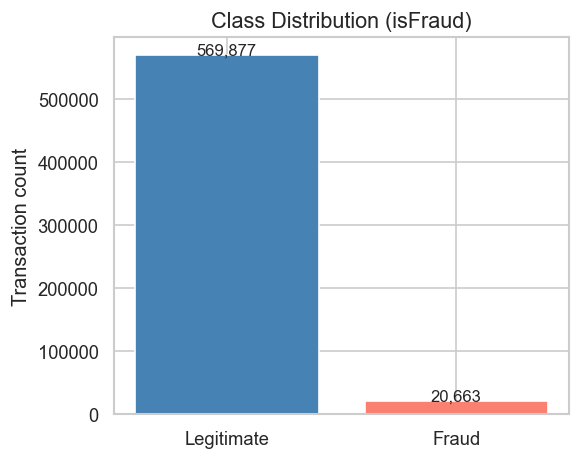

In [13]:
fraud_counts = df["isFraud"].value_counts()
fraud_rate = df["isFraud"].mean() * 100

print(f"Legitimate transactions : {fraud_counts[0]:,}  ({100 - fraud_rate:.1f}%)")
print(f"Fraudulent transactions : {fraud_counts[1]:,}  ({fraud_rate:.1f}%)")
print(f"\nImbalance ratio (legit:fraud) : {fraud_counts[0] // fraud_counts[1]}:1")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Legitimate", "Fraud"], fraud_counts.values,
       color=["steelblue", "salmon"], edgecolor="white")
ax.set_title("Class Distribution (isFraud)", fontsize=13)
ax.set_ylabel("Transaction count")
for i, v in enumerate(fraud_counts.values):
    ax.text(i, v + 1000, f"{v:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_class_distribution.png")
plt.show()

the ~3.5% fraud rate means accuracy is a useless metric. All evaluation going forward uses precision, recall, F1, and PR-AUC on the fraud class only.

Columns with missing values: 414 / 434
Columns with >90% missing (will be dropped): 12


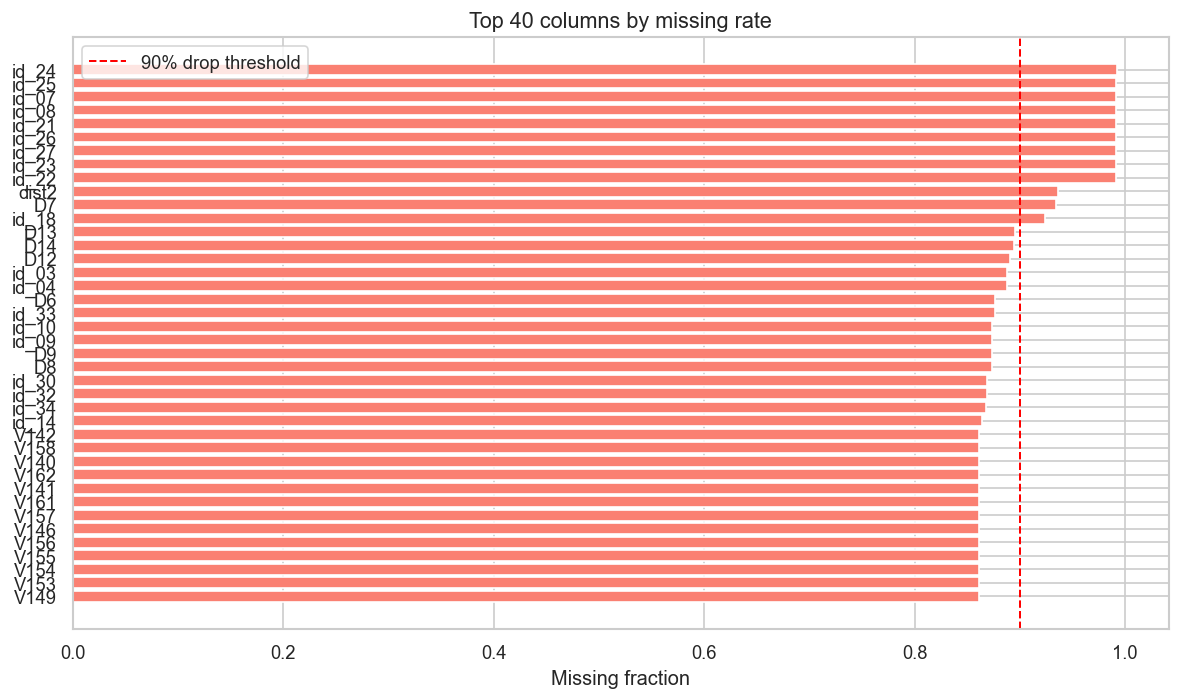

In [14]:
# compute missing % per column, keep only columns with any missing data
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]

print(f"Columns with missing values: {len(missing)} / {df.shape[1]}")
print(f"Columns with >90% missing (will be dropped): {(missing > 0.9).sum()}")

# heatmap on top 40 most-missing columns only (full 400+ is unreadable)
top_missing = missing.head(40)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_missing.index[::-1], top_missing.values[::-1],
               color="salmon", edgecolor="white")
ax.axvline(0.9, color="red", linestyle="--", linewidth=1.2, label="90% drop threshold")
ax.set_xlabel("Missing fraction")
ax.set_title("Top 40 columns by missing rate", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_missingness.png")
plt.show()

columns above the 90% threshold will be dropped in preprocessing since they carry almost no signal and would require extreme imputation assumptions. The remaining missing values will be filled with -999 for numeric columns (a sentinel value tree models handle natively) and "missing" for categoricals

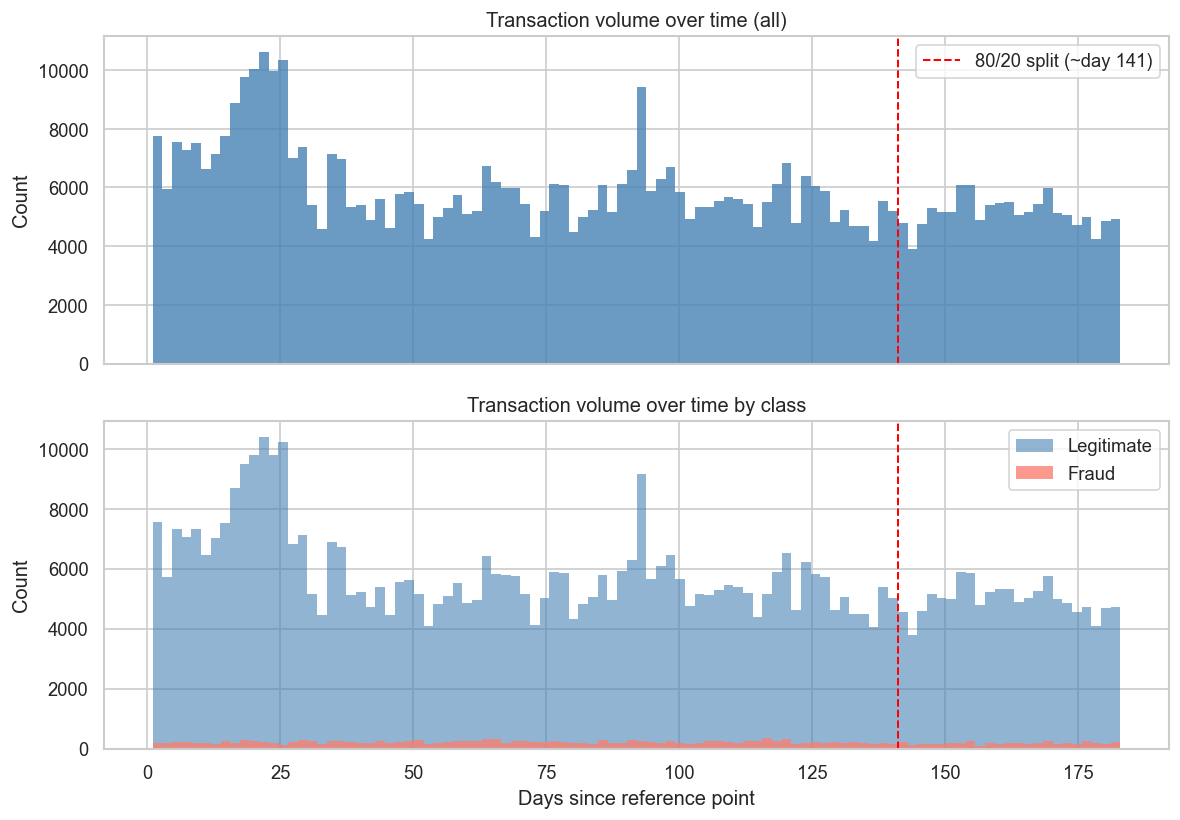

Time span: 1 to 183 days
80/20 split point: day 141


In [15]:
# TransactionDT is seconds since a reference point. Converted to days for readability
df["txn_day"] = df["TransactionDT"] / (24 * 3600)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# all transactions
axes[0].hist(df["txn_day"], bins=100, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].set_title("Transaction volume over time (all)", fontsize=12)
axes[0].set_ylabel("Count")

# fraud only overlay
fraud = df[df["isFraud"] == 1]
legit = df[df["isFraud"] == 0]
axes[1].hist(legit["txn_day"], bins=100, color="steelblue",
             alpha=0.6, label="Legitimate", edgecolor="none")
axes[1].hist(fraud["txn_day"], bins=100, color="salmon",
             alpha=0.8, label="Fraud", edgecolor="none")
axes[1].set_title("Transaction volume over time by class", fontsize=12)
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Days since reference point")
axes[1].legend()

# mark the 80/20 time split point for train/test
split_day = df["txn_day"].quantile(0.8)
for ax in axes:
    ax.axvline(split_day, color="red", linestyle="--",
               linewidth=1.2, label=f"80/20 split (~day {split_day:.0f})")
axes[0].legend()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_transactionDT_distribution.png")
plt.show()

print(f"Time span: {df['txn_day'].min():.0f} to {df['txn_day'].max():.0f} days")
print(f"80/20 split point: day {split_day:.0f}")

TransactionDT confirms this is real time-ordered data spanning roughly 6 months. This is exactly why we use a time-based train/test split rather than a random stratified one. A random split would leak future fraud patterns into training and inflate evaluation metrics.

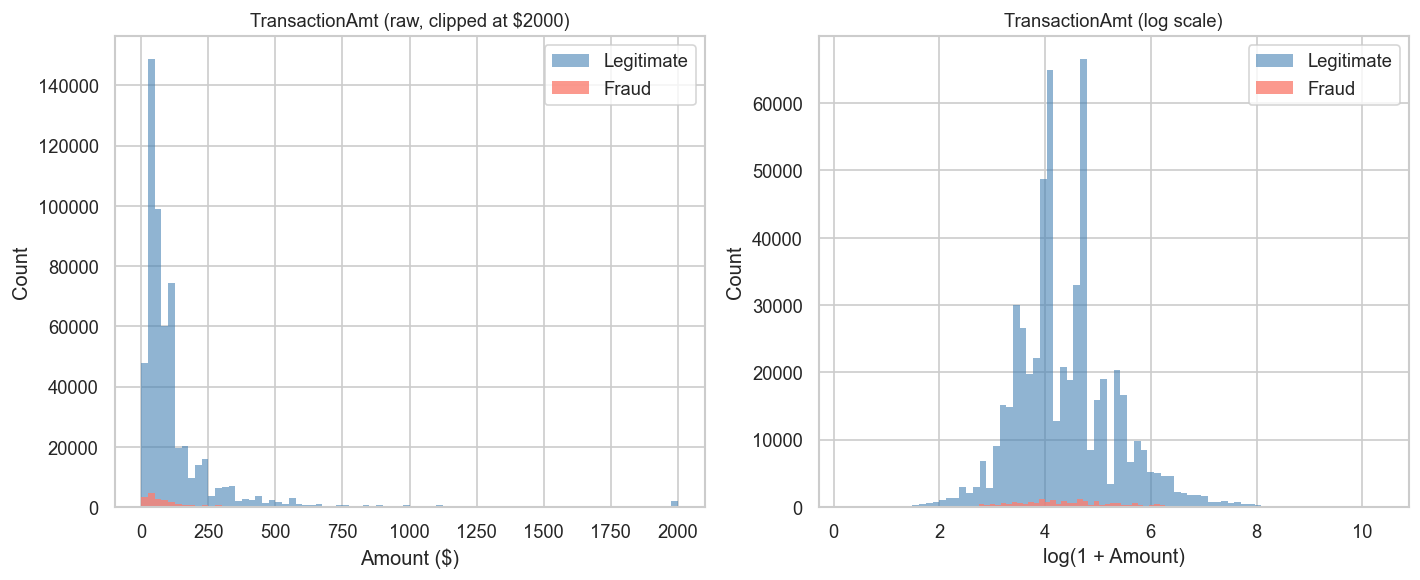

TransactionAmt statistics by class:


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.51,239.40,0.25,43.97,68.5,120.0,31937.39
1,20663.0,149.24,232.21,0.29,35.04,75.0,161.0,5191.00


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# raw amount — skewed, hard to read
axes[0].hist(df[df["isFraud"]==0]["TransactionAmt"].clip(upper=2000), #maximum allowed value
             bins=80, color="steelblue", alpha=0.6, label="Legitimate", edgecolor="none")
axes[0].hist(df[df["isFraud"]==1]["TransactionAmt"].clip(upper=2000),
             bins=80, color="salmon", alpha=0.8, label="Fraud", edgecolor="none")
axes[0].set_title("TransactionAmt (raw, clipped at $2000)", fontsize=11)
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Count")
axes[0].legend()

# log-transformed — much more informative
log_amt = np.log1p(df["TransactionAmt"])
axes[1].hist(log_amt[df["isFraud"]==0], bins=80, color="steelblue",
             alpha=0.6, label="Legitimate", edgecolor="none")
axes[1].hist(log_amt[df["isFraud"]==1], bins=80, color="salmon",
             alpha=0.8, label="Fraud", edgecolor="none")
axes[1].set_title("TransactionAmt (log scale)", fontsize=11)
axes[1].set_xlabel("log(1 + Amount)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_transaction_amount.png")
plt.show()

print("TransactionAmt statistics by class:")
df.groupby("isFraud")["TransactionAmt"].describe().round(2)

 the log-transformed view reveals that fraudulent transactions cluster at both lower and higher amounts than legitimate ones, suggesting log(TransactionAmt) will be a more informative feature for linear models than the raw value.

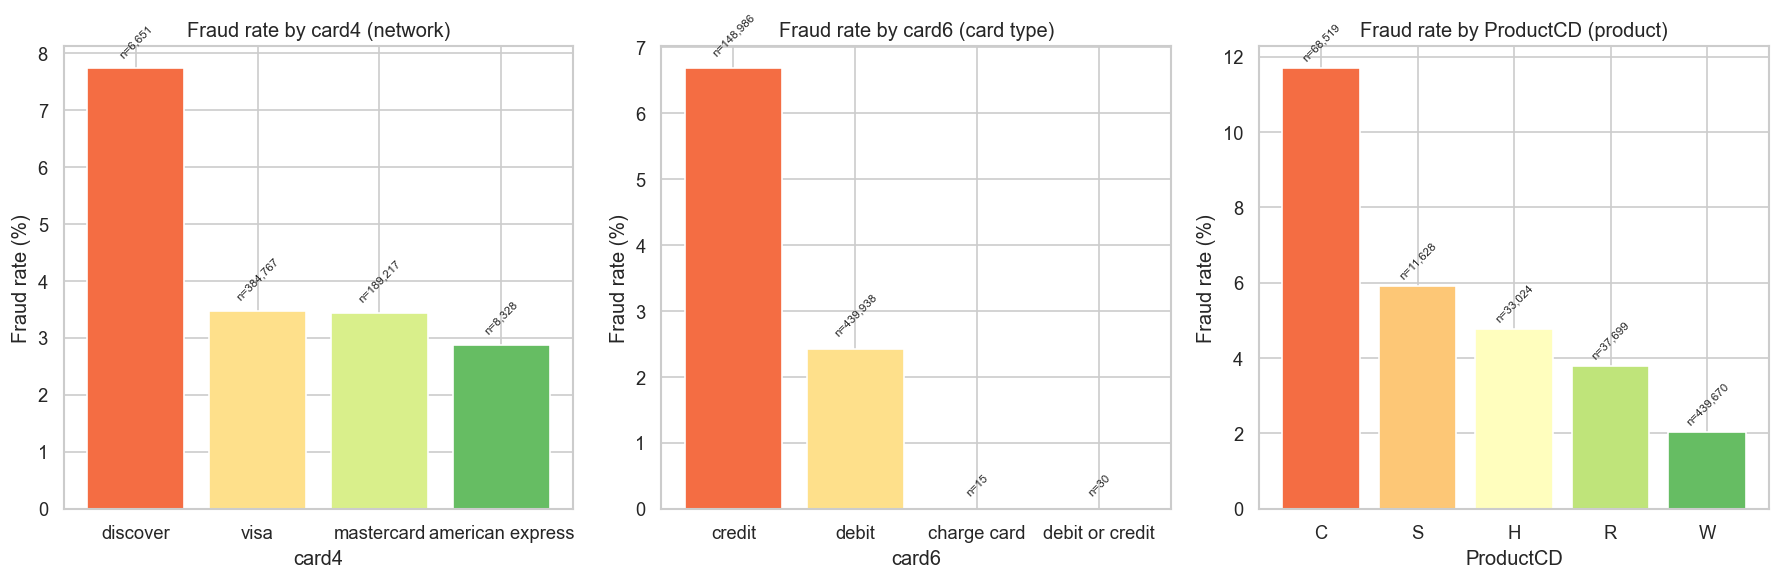

In [19]:
#For each category of a feature, what percentage of transactions are fraudulent?
def fraud_rate_plot(col, ax, title):
    stats = (df.groupby(col)["isFraud"]
               .agg(["mean", "count"])
               .rename(columns={"mean": "fraud_rate", "count": "volume"})
               .sort_values("fraud_rate", ascending=False)
               .reset_index())
    
    color_map = plt.cm.RdYlGn_r(np.linspace(0.8, 0.2, len(stats)))
    bars = ax.bar(stats[col].astype(str), stats["fraud_rate"] * 100,
                  color=color_map, edgecolor="white")
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Fraud rate (%)")
    ax.set_xlabel(col)
    
    # annotate with volume
    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f"n={row['volume']:,}", ha="center",
                fontsize=7, rotation=45)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fraud_rate_plot("card4", axes[0], "Fraud rate by card4 (network)")
fraud_rate_plot("card6", axes[1], "Fraud rate by card6 (card type)")
fraud_rate_plot("ProductCD", axes[2], "Fraud rate by ProductCD (product)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05_fraud_rate_breakdowns.png")
plt.show()

Note the number of transactions (n) in each category, some categories may show extreme fraud rates simply because they appear very rarely in the data (a category with 3 transactions, 2 of which are fraud, looks like 67% fraud rate but is statistically meaningless). This is why raw category labels will be frequency-encoded rather than one-hot encoded. Frequency encoding naturally down-weights rare categories.

In [20]:
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)
print(f"Total transactions      : {len(df):,}")
print(f"Features                : {df.shape[1]}")
print(f"Fraud rate              : {df['isFraud'].mean()*100:.2f}%")
print(f"Time span               : {df['txn_day'].max() - df['txn_day'].min():.0f} days")
print(f"Cols >90% missing       : {(df.isna().mean() > 0.9).sum()}")
print(f"Median transaction amt  : ${df['TransactionAmt'].median():.2f}")
print(f"Median fraud amt        : ${df[df['isFraud']==1]['TransactionAmt'].median():.2f}")
print("=" * 50)
print("Key decisions going forward:")
print("  - Time-based 80/20 train/test split")
print("  - Drop columns with >90% missing")
print("  - Frequency encoding for categoricals")
print("  - Evaluate on precision/recall/F1/PR-AUC (not accuracy)")
print("  - Log-transform TransactionAmt for logistic regression baseline")

EDA SUMMARY
Total transactions      : 590,540
Features                : 435
Fraud rate              : 3.50%
Time span               : 182 days
Cols >90% missing       : 12
Median transaction amt  : $68.77
Median fraud amt        : $75.00
Key decisions going forward:
  - Time-based 80/20 train/test split
  - Drop columns with >90% missing
  - Frequency encoding for categoricals
  - Evaluate on precision/recall/F1/PR-AUC (not accuracy)
  - Log-transform TransactionAmt for logistic regression baseline
